# 프로젝트1 당뇨병 수치 맞추기

## 데이터 가져오기, 데이터 확인
sklearn의 load_diabetes에서 데이터를 불러왔습니다. 
데이터를 확인 해 봤을 때 데이터는 442개의 환자 데이터와 10의 특성을 가지고 있었습니다. df_x값
또한 답안지로 보이는 y 값은 당뇨병 진행 수치로 파악이 됩니다. df_y
자세한 데이터를 확인해 보고 싶었지만 이미 정규화가 된것을 확인하고 데이터를 더 이상 손볼 필요가 없다는 생각을 했습니다. 

In [74]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
df_X = diabetes.data
df_y = diabetes.target

In [75]:
print(df_X.shape)
print(df_y.shape)

(442, 10)
(442,)


In [76]:
type(df_X)

numpy.ndarray

In [77]:
X = df_X
y = df_y 


In [78]:
X[:5]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087]])

In [79]:
y[:5]

array([151.,  75., 141., 206., 135.])

 ## 모델 학습
 데이터를 학습용 80%와 검증용 20%로 분리했습니다. 
 학습후에 제대로 학습이 되었는지 확인하기 위해서입니다. 
 가중치 w를 특성수에 맞춰 10개로 넣었으며 초기값을 0으로 잡았습니다. 
 모델 함수는 np.dot(x, w)+b로 각 특성에 가중치를 곱해서 더하는 선형 모델입니다. 
 초기 모델 테스트에서는 모델의 초기값 그대로 학습을 시켰고 여기에 기울기나 경사하강법은 쓰이지 않았습니다. 
 결과 로스는 29711.32294617564 이 나왔습니다. 

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
import numpy as np
W = np.zeros(10)
b = 0.0

In [82]:
def model(X, W, b):
    return np.dot(X, W) + b

In [83]:
def loss(X, W, b, y):
    prediction = model(X, W, b)
    error = prediction - y 
    mse = np.mean(error ** 2)
    return mse

In [84]:
loss(X_train, W, b, y_train)

np.float64(29711.32294617564)

## 모델 가중치 수정: 기울기, 경사하강법 적용 
손실함수를 MSE로 정의했습니다. 왜냐면 손실함수의 식이 MSE와 유사하기 때문입니다. 
기울기를 구하는 함수는 가중치를 변화시켜 loss 가 어떻게 변하는지 측정하는 방식입니다 
기울기를 구해 경사하강법을 통해 학습률을 적용시킬수 있기 때문입니다 

학습률은 0.01로 설정, 학습횟수는 50000을 학습시킨 결과 loss는 29000에서 2900까지 줄었습니다. 
test 데이터에서도 MSE는 2870으로 3천 이하를 달성했습니다. 


In [85]:
def gradient(X, W, b, y):
    dW = np.zeros_like(W)
    db = 0.0
    h = 0.0001

    for i in range(len(W)):
        W[i] += h
        loss_up = loss(X, W, b, y)
        W[i] -= h
        dW[i] = (loss_up - loss(X, W, b, y)) / h
    
    b += h
    loss_up = loss(X, W, b, y)
    b -= h
    db = (loss_up - loss(X, W, b, y)) / h

    return dW, db


In [86]:
learning_rate = 0.01

In [90]:
learning_rate = 0.01
losses = []

for i in range(50000):
    dW, db = gradient(X_train, W, b, y_train)
    W = W - learning_rate * dW
    b = b - learning_rate * db
    
    if i % 1000 == 0:
        current_loss = loss(X_train, W, b, y_train)
        losses.append(current_loss)
        print(f"step {i}: loss = {current_loss:.2f}")

step 0: loss = 2895.74
step 1000: loss = 2895.72
step 2000: loss = 2895.70
step 3000: loss = 2895.67
step 4000: loss = 2895.65
step 5000: loss = 2895.63
step 6000: loss = 2895.60
step 7000: loss = 2895.58
step 8000: loss = 2895.56
step 9000: loss = 2895.53
step 10000: loss = 2895.51
step 11000: loss = 2895.49
step 12000: loss = 2895.46
step 13000: loss = 2895.44
step 14000: loss = 2895.42
step 15000: loss = 2895.40
step 16000: loss = 2895.37
step 17000: loss = 2895.35
step 18000: loss = 2895.33
step 19000: loss = 2895.30
step 20000: loss = 2895.28
step 21000: loss = 2895.26
step 22000: loss = 2895.24
step 23000: loss = 2895.21
step 24000: loss = 2895.19
step 25000: loss = 2895.17
step 26000: loss = 2895.15
step 27000: loss = 2895.12
step 28000: loss = 2895.10
step 29000: loss = 2895.08
step 30000: loss = 2895.06
step 31000: loss = 2895.03
step 32000: loss = 2895.01
step 33000: loss = 2894.99
step 34000: loss = 2894.97
step 35000: loss = 2894.94
step 36000: loss = 2894.92
step 37000: lo

In [91]:
test_loss = loss(X_test, W, b, y_test)
print(f"test MSE: {test_loss:.2f}")

test MSE: 2885.11


## 시각화 
x_test의 특성을 x축 타겟을 y 축으로 잡아 실제값과 예측값을 시각화 했습니다. 


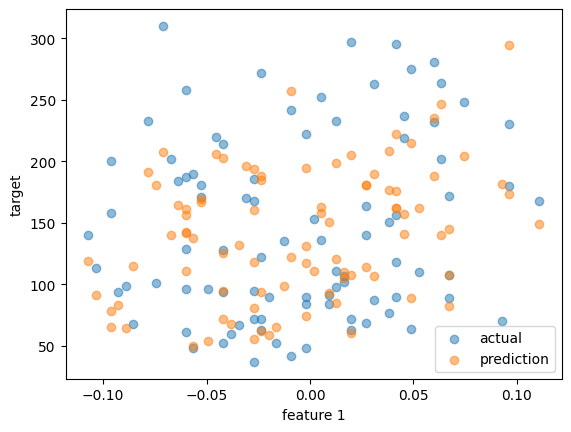

In [92]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test, label='actual', alpha=0.5)
plt.scatter(X_test[:, 0], model(X_test, W, b), label='prediction', alpha=0.5)
plt.xlabel('feature 1')
plt.ylabel('target')
plt.legend()
plt.show()

## 프로젝트 2: 자전거 타는 사람은 몇명? 
우선 데이터셋을 받아서 바로 head()로 컬럼과 값을 확인했습니다. 
이후 datetime을 세분화 해서 연/월/일/시/분/초 로 쪼갰습니다. 
이 쪼갠 데이터를 가시화를 통해 분포를 확인하고 데이터 중에서는 분과 초 단위의 데이터는 굳이 필요가 없을것 같다는 판단을 했습니다. 


In [70]:
import pandas as pd
train = pd.read_csv(r'C:\Users\akals\Downloads\새 폴더 (2)\train.csv')
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [74]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

In [72]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


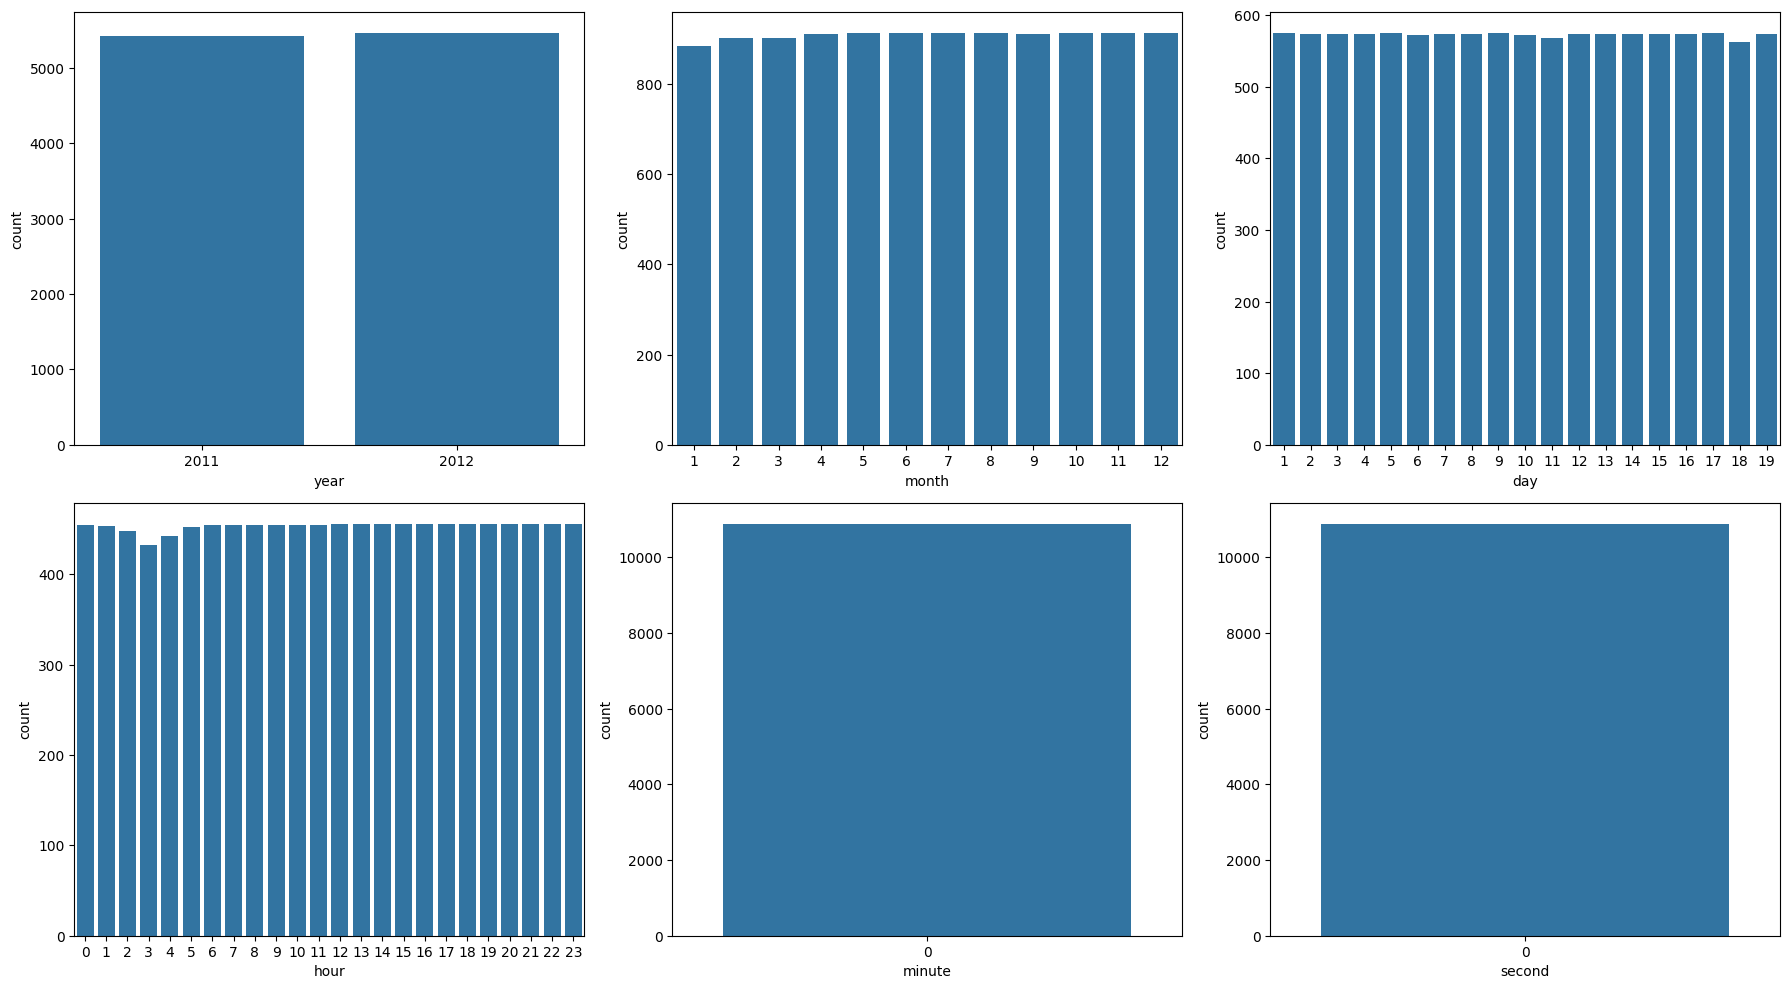

In [79]:

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x='year', data=train, ax=axes[0][0])
sns.countplot(x='month', data=train, ax=axes[0][1])
sns.countplot(x='day', data=train, ax=axes[0][2])
sns.countplot(x='hour', data=train, ax=axes[1][0])
sns.countplot(x='minute', data=train, ax=axes[1][1])
sns.countplot(x='second', data=train, ax=axes[1][2])

plt.tight_layout()
plt.show()

## 피처 선택, 학습, 결과 
우선 컬럼에는 분과 초 그리고 회원과 비회원의 자전거를 빌린 횟수 역시 제거했습니다. 
회원+비회원=전체 갯수가 되기 때문에 이를 모델이 학습하면 모델은 오히려 자전거 대여 예측모델이 아니라 회원+비훠원 값을 예측하는 
더하기 도구가 되어버린다는 생각을 했습니다. 
모델은 sklearn에서 받아서 사용하고 학습 역시 준비한 데이터셋으로 학습을 했습니다. 
나온 점수는 
MSE: 19945.37
RMSE: 141.23
이고 이것을 가시화 하면 가장 아래에 있는 그래프가 나옵니다. 예측범위가 좁기 때문에 800대의 변화에 대해서는 잡지 못하는 것 같습니다. 

In [80]:
feature_columns = ['season', 'holiday', 'workingday', 'weather', 
                   'temp', 'atemp', 'humidity', 'windspeed',
                   'year', 'month', 'day', 'hour']
X = train[feature_columns]
y = train['count']

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
import numpy as np

prediction = model.predict(X_test)
mse = np.mean((prediction - y_test) ** 2)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MSE: 19945.37
RMSE: 141.23


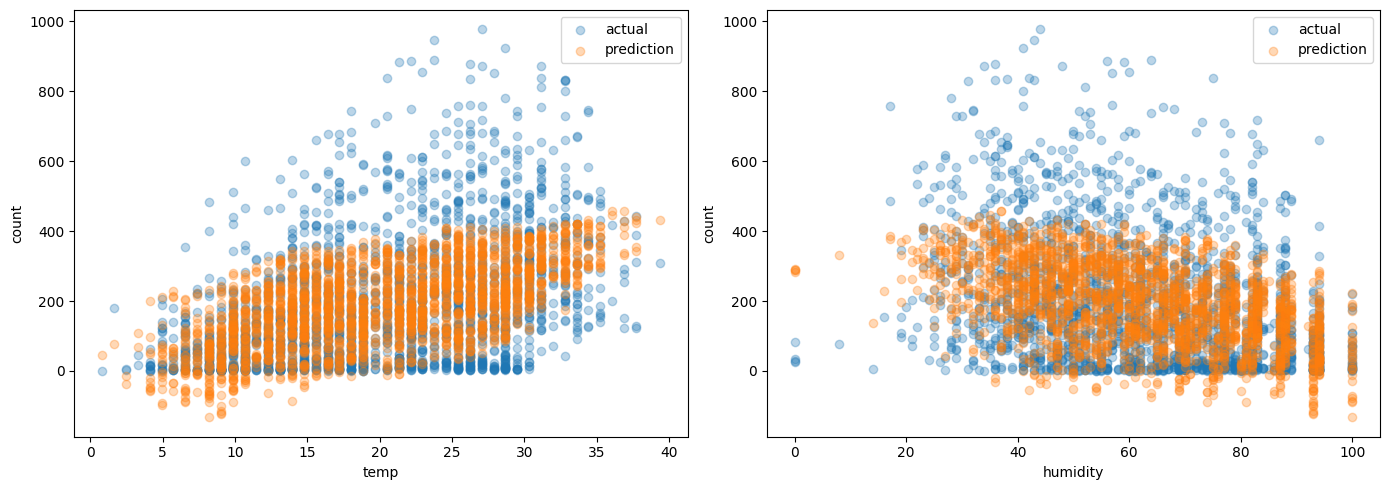

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_test['temp'], y_test, alpha=0.3, label='actual')
axes[0].scatter(X_test['temp'], prediction, alpha=0.3, label='prediction')
axes[0].set_xlabel('temp')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].scatter(X_test['humidity'], y_test, alpha=0.3, label='actual')
axes[1].scatter(X_test['humidity'], prediction, alpha=0.3, label='prediction')
axes[1].set_xlabel('humidity')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 번외
우선 모델성능에서의 예측범위가 좁기 때문에 결국 개선을 하더라도 해당 모델에서는 RMSE에서 100점을 넘기는 어려울것 같았습니다. 
그래서 다른 모델인 랜덤 포레스트를 설치해서 돌려보기로 했습니다. 


In [90]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

prediction_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(np.mean((prediction_rf - y_test) ** 2))
print(f"RMSE: {rmse_rf:.2f}")

RMSE: 42.41


In [91]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

params = [
    {'n_estimators': 50, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': None},
    {'n_estimators': 500, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 100, 'max_depth': 50},
    {'n_estimators': 300, 'max_depth': 20},
    {'n_estimators': 500, 'max_depth': 20},
]

for p in params:
    rf = RandomForestRegressor(**p, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    rmse = np.sqrt(np.mean((pred - y_test) ** 2))
    print(f"n_estimators={p['n_estimators']}, max_depth={p['max_depth']} → RMSE: {rmse:.2f}")

n_estimators=50, max_depth=None → RMSE: 42.67
n_estimators=100, max_depth=None → RMSE: 42.41
n_estimators=300, max_depth=None → RMSE: 42.06
n_estimators=500, max_depth=None → RMSE: 41.89
n_estimators=100, max_depth=5 → RMSE: 103.35
n_estimators=100, max_depth=10 → RMSE: 47.30
n_estimators=100, max_depth=20 → RMSE: 42.41
n_estimators=100, max_depth=50 → RMSE: 42.41
n_estimators=300, max_depth=20 → RMSE: 42.09
n_estimators=500, max_depth=20 → RMSE: 41.89


### 어떤 항목에서 영향을 많이 받는지??? 
각 파라미터별 RMSE 값을 확인했을 때 적정값을 찾아 
n_estimators=500, max_depth=None → RMSE: 41.89 일때가 가장 값이 좋게 나오지 않나 라는 생각을 했습니다. 
다음은 데이터셋의 컬럼을 수정해서 점수를 높일수 있는지에 대해서 생각해봤습니다. 
우선 모델이 어떤 항목에 영향을 많이 받는지 확인했고 시간에 많은 영향을 받는다는 것을 알았습니다. 


In [92]:
import pandas as pd

importance = pd.Series(model_rf.feature_importances_, index=feature_columns)
print(importance.sort_values(ascending=False))

hour          0.602125
year          0.086252
workingday    0.079974
temp          0.055824
atemp         0.049507
month         0.047851
humidity      0.029478
weather       0.015085
day           0.012244
season        0.009785
windspeed     0.009625
holiday       0.002250
dtype: float64


In [93]:
train['hour_squared'] = train['hour'] ** 2
train['hour_workingday'] = train['hour'] * train['workingday']
train['temp_humidity'] = train['temp'] * train['humidity']

feature_columns4 = feature_columns + ['hour_squared', 'hour_workingday', 'temp_humidity']

X4 = train[feature_columns4]
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size=0.2, random_state=42)

rf4 = RandomForestRegressor(n_estimators=100, random_state=42)
rf4.fit(X4_train, y4_train)
pred4 = rf4.predict(X4_test)
rmse4 = np.sqrt(np.mean((pred4 - y4_test) ** 2))
print(f"RMSE: {rmse4:.2f}")

RMSE: 41.42


In [94]:
# 시간대 구간 나누기
train['is_rush_hour'] = train['hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)
train['is_night'] = train['hour'].apply(lambda x: 1 if x in [0,1,2,3,4,5] else 0)
train['is_afternoon'] = train['hour'].apply(lambda x: 1 if x in [12,13,14] else 0)

# 출퇴근 × 평일 조합
train['rush_workday'] = train['is_rush_hour'] * train['workingday']
train['night_weekend'] = train['is_night'] * (1 - train['workingday'])

# 온도 쾌적 구간
train['nice_weather'] = ((train['temp'] > 15) & (train['temp'] < 30) & (train['humidity'] < 60)).astype(int)

feature_columns5 = feature_columns + ['hour_squared', 'hour_workingday', 'temp_humidity',
                                       'is_rush_hour', 'is_night', 'is_afternoon',
                                       'rush_workday', 'night_weekend', 'nice_weather']

X5 = train[feature_columns5]
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y, test_size=0.2, random_state=42)

rf5 = RandomForestRegressor(n_estimators=300, random_state=42)
rf5.fit(X5_train, y5_train)
pred5 = rf5.predict(X5_test)
rmse5 = np.sqrt(np.mean((pred5 - y5_test) ** 2))
print(f"RMSE: {rmse5:.2f}")

RMSE: 41.85


In [95]:
error = y_test.values - model_rf.predict(X_test)
error_df = pd.DataFrame({
    'hour': X_test['hour'].values,
    'error': error,
    'abs_error': np.abs(error)
})
print(error_df.groupby('hour')['abs_error'].mean().sort_values(ascending=False).head(10))

hour
16    52.147172
18    44.224458
8     43.178500
17    42.716500
19    41.929778
7     35.344949
11    33.269895
21    31.807864
9     31.794400
13    30.163168
Name: abs_error, dtype: float64


In [99]:
# 0=평일, 1=주말, 2=공휴일
train['day_type'] = 0
train.loc[(train['workingday'] == 0) & (train['holiday'] == 0), 'day_type'] = 1
train.loc[train['holiday'] == 1, 'day_type'] = 2

# 이걸 hour랑 조합
train['hour_daytype'] = train['hour'] * 10 + train['day_type']

In [100]:
feature_columns6 = feature_columns + ['hour_squared', 'hour_workingday', 'temp_humidity', 'day_type', 'hour_daytype']

X6 = train[feature_columns6]
X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y, test_size=0.2, random_state=42)

rf6 = RandomForestRegressor(n_estimators=300, random_state=42)
rf6.fit(X6_train, y6_train)
pred6 = rf6.predict(X6_test)
rmse6 = np.sqrt(np.mean((pred6 - y6_test) ** 2))
print(f"RMSE: {rmse6:.2f}")

RMSE: 41.79


## 최종
시간을 나누는 항목에서 주말은 따로 공휴일로 지정되어있지 않아 이것을 따로 공휴일로 만들어 주면 날짜를 판별하는 분별력이 생길줄 알았지만 점수가 올라가지 않았고 아마도 이건 이미 모델 내에서 해당 패턴에 대한 학습을 했기 때문에 항목을 수정한 일이 불필요하게 되었다고 생각했습니다. 
